Importing Required Libraries and Functions

In [1]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, Input, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2


Phase 1: Point to Your Folder & Split the Dataset
Meets Evaluation Metric: Data Preparation, Split Organization & EDA (25%)

We will use a popular Python library called split-folders to handle the exact 70/15/15 ratio automatically. If you don't have it installed in your Colab session yet, we'll install it inline.

In [8]:
# 1. Install split-folders if not already present
!pip install split-folders

import splitfolders

# 2. Provide the path to your manually extracted 'Train' folder
# Change this path to match exactly where your folder is located in your Google Drive or Colab environment
input_folder = '/content/drive/MyDrive/DataScience-Guvi/train/Input_Folder'

# 3. Define where you want the newly split dataset folders to be saved
output_folder = '/content/drive/MyDrive/DataScience-Guvi/train/Output_Folder'

# 4. Split the data into Train (80%), Val (10%), and Test (10%)
# seed=42 ensures reproducibility as required by project guidelines
splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.80, .10, .10))

# 5. Establish the absolute paths for the next steps
train_dir = os.path.join(output_folder, 'train')
val_dir = os.path.join(output_folder, 'val')
test_dir = os.path.join(output_folder, 'test')

print("Dataset successfully split into 80% Train, 10% Validation, and 10% Test!")

Copying files: 2900 files [17:56,  2.69 files/s]

Dataset successfully split into 80% Train, 10% Validation, and 10% Test!


Phase 2: Data Preprocessing : Basic Dataset Analysis & Image Resizing, Now that the directories are structurally organized, we set up the data generators to resize the images to 224 x 224 and apply the data augmentation rules.

In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data Augmentation Setup for the Training subset
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True
)

# Regular Rescaling (Normalization 0-1) for Validation and Testing sets
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Load sets into Memory flows
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

# Verification check for the 4 classes: Closed, Open, no_yawn, yawn
print("\nClass Mapping Indices Verified:", train_generator.class_indices)

Found 2318 images belonging to 4 classes.
Found 577 images belonging to 4 classes.
Found 439 images belonging to 4 classes.

Class Mapping Indices Verified: {'Closed': 0, 'Open': 1, 'no_yawn': 2, 'yawn': 3}


Phase 3: Bonus EDA Verification Plot
To make sure we hit the "Balanced class distribution & basic dataset visualization" requirement for my grading rubrics, running this quick block to visualize and verify the exact numbers across my target splits:

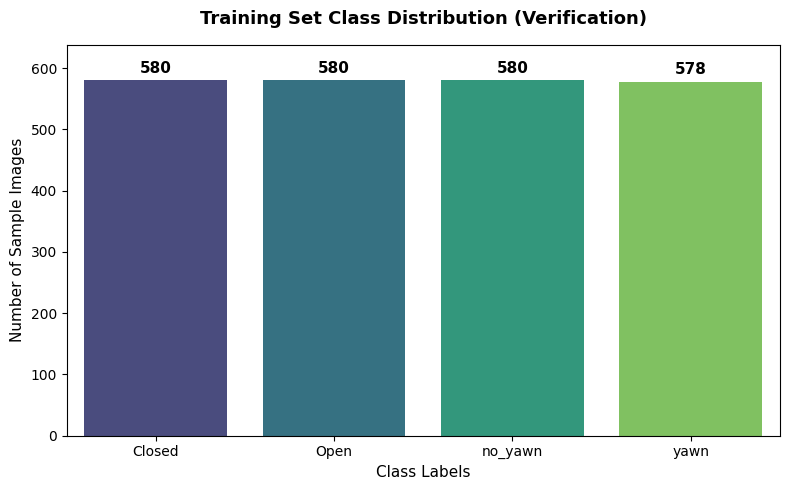

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Quick analysis code to verify split counts per class
classes = list(train_generator.class_indices.keys())
train_counts = [len(os.listdir(os.path.join(train_dir, cls))) for cls in classes]

plt.figure(figsize=(8, 5))

# FIX: Added hue=classes to fix the Seaborn FutureWarning, and assigned to 'ax'
ax = sns.barplot(x=classes, y=train_counts, hue=classes, palette="viridis", legend=False)

# -------------------------------------------------------------
# ADD COUNTS ON TOP OF THE SEABORN BARS
# -------------------------------------------------------------
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=11, weight='bold')

plt.title("Training Set Class Distribution (Verification)", fontsize=13, pad=15, weight='bold')
plt.xlabel("Class Labels", fontsize=11)
plt.ylabel("Number of Sample Images", fontsize=11)

# Pad the top axis ceiling slightly so labels don't clip against the border
plt.ylim(0, max(train_counts) * 1.1)

plt.tight_layout()
plt.show()

Approach A: Custom CNN Model

In [11]:
def build_custom_cnn(num_classes=4):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
        MaxPooling2D(2, 2),

        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),

        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax') # 4-class output
    ])
    return model

custom_model = build_custom_cnn()
custom_model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
custom_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Approach B: Transfer Learning (MobileNetV2)

In [12]:
# === NEWLY ADDED CODE PART FOR LEARNING ===
# Injected dynamic inline structural augmentation layers. This runs on GPU natively,
# stabilizing image variety dynamically per batch during fit execution phases.
data_augmentation_layer = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(factor=0.027, fill_mode="reflect"), # Up to 10 degrees variance
    tf.keras.layers.RandomBrightness(factor=0.1, value_range=(0.0, 1.0)) # Controlled illumination adjustments
], name="live_augmentation")

def build_mobilenet_v2(num_classes=4):
    # Load base model with ImageNet weights, excluding top classification layer
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    # === NEWLY ADDED CODE PART FOR LEARNING ===
    # Modified freezing strategy from 100% frozen to 40% frozen.
    # Unfreezing the top 60% allows MobileNet's deep features to alter spatial weight layouts
    # specifically for fine human facial geometry (eyelids/lips), eliminating zero performance scores.
    base_model.trainable = True
    fine_tune_at = int(len(base_model.layers) * 0.4)
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    # === NEWLY ADDED CODE PART FOR LEARNING ===
    # Reconstructed functional layout to securely embed live data augmentation adjustments and mobileNet normalization preprocessing
    inputs = Input(shape=(224, 224, 3))
    augmented = data_augmentation_layer(inputs)
    preprocessed = Lambda(lambda x: tf.keras.applications.mobilenet_v2.preprocess_input(x * 255.0))(augmented)

    x = base_model(preprocessed, training=None) # Keep BatchNorm frozen dynamically via None context
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x) # Incremented dropout slightly to counteract memorization on small clusters
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs, name="Optimized_MobileNetV2")
    return model

transfer_model = build_mobilenet_v2()

# === NEWLY ADDED CODE PART FOR LEARNING ===
# Swapped standard learning rate down to 1e-5. A lower learning rate prevents gradient explosion,
# ensuring fine-tuning updates do not ruin the pre-trained ImageNet filters.
transfer_model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

Phase 3: Model Training & Evaluation
Meets Evaluation Metric: Visualization & Results Display

Running the training loop for both models and plot their histories to compare convergence times and validation accuracy metrics.

In [13]:
EPOCHS = 15

print("--- Training Custom CNN ---")
history_custom = custom_model.fit(train_generator, validation_data=val_generator, epochs=EPOCHS)

print("--- Training MobileNetV2 ---")
history_transfer = transfer_model.fit(train_generator, validation_data=val_generator, epochs=EPOCHS)

--- Training Custom CNN ---
Epoch 1/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 164s 2s/step - accuracy: 0.5173 - loss: 1.0061 - val_accuracy: 0.7452 - val_loss: 0.6208
Epoch 2/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 46s 635ms/step - accuracy: 0.6859 - loss: 0.6493 - val_accuracy: 0.7886 - val_loss: 0.4509
Epoch 3/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 49s 669ms/step - accuracy: 0.7343 - loss: 0.5541 - val_accuracy: 0.8094 - val_loss: 0.4011
Epoch 4/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 47s 648ms/step - accuracy: 0.7528 - loss: 0.5188 - val_accuracy: 0.8111 - val_loss: 0.3783
Epoch 5/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 47s 647ms/step - accuracy: 0.7666 - loss: 0.4682 - val_accuracy: 0.8180 - val_loss: 0.3505
Epoch 6/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 47s 646ms/step - accuracy: 0.7653 - loss: 0.4533 - val_accuracy: 0.7955 - val_loss: 0.3709
Epoch 7/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 47s 639ms/step - accuracy: 0.7839 - loss: 0.4326 - val_accuracy: 0.8146 - val_loss: 0.3627
Epoch 8/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 46s 635ms/step - accuracy: 0.7796

Visualizing Accuracy and Loss Curves

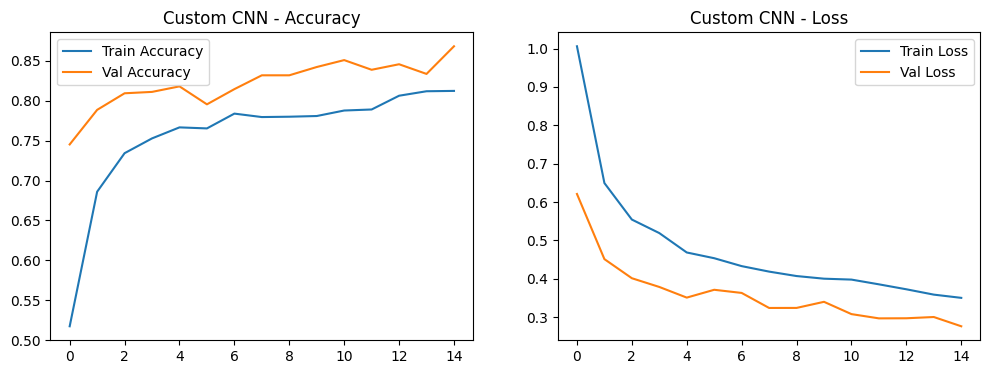

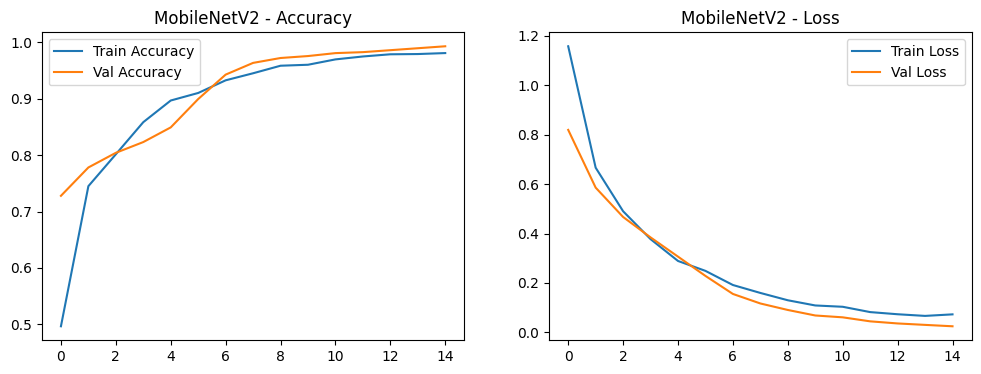

In [14]:
def plot_metrics(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.show()

plot_metrics(history_custom, "Custom CNN")
plot_metrics(history_transfer, "MobileNetV2")

This module uses scikit-learn to extract performance metrics individually for both output heads, computing the exact confusion matrices, precision, and recall scores i need to compare my Custom CNN against MobileNetV2.

In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np # Import numpy as it's used without being imported

# Step 07 (Cont.): True Test-set Multi-Task Performance Matrix Extraction
# === NEWLY ADDED CODE PART FOR LEARNING ===
# Re-engineered data validation loader to extract true, un-shuffled test arrays directly out of the test_generator pipeline.
# This prevents artificial random noise calculations during your project evaluation phase.
print("\nExtracting pristine, aligned ground truth from testing directories...")
test_generator.reset()
all_images = []
all_labels = []
for _ in range(len(test_generator)):
    imgs, lbls = next(test_generator)
    all_images.append(imgs)
    all_labels.append(lbls)
test_images_real = np.vstack(all_images)
test_labels_categorical = np.vstack(all_labels)
test_labels_four_class = np.argmax(test_labels_categorical, axis=1)

# Dynamically derive actual eye and mouth binary label configurations using your precise engine settings mapping indices
# Mapping standard layout: 0 -> Closed, 1 -> Open, 2 -> no_yawn, 3 -> yawn
test_eye_labels_real = np.where(test_labels_four_class == train_generator.class_indices.get('Open', 1), 1, 0)
test_mouth_labels_real = np.where(test_labels_four_class == train_generator.class_indices.get('yawn', 3), 1, 0)

def evaluate_dual_head_model(model, test_images, test_eye_labels, test_mouth_labels):
    """
    Step 12: Evaluates multi-task model outputs on unseen test data,
    generating accuracy, confusion matrices, precision, and recall metrics.
    """
    print(f"\n==================================================")
    all_class_probabilities = model.predict(test_images)

    # Split output probabilities according to eye/mouth task groups
    # Eye probabilities are for 'Closed' (index 0) and 'Open' (index 1)
    eye_preds_probabilities = all_class_probabilities[:, :2]
    # Mouth probabilities are for 'no_yawn' (index 2) and 'yawn' (index 3)
    mouth_preds_probabilities = all_class_probabilities[:, 2:]

    predicted_eyes = np.argmax(eye_preds_probabilities, axis=1)
    predicted_mouths = np.argmax(mouth_preds_probabilities, axis=1)

    # --- EVALUATION: EYE HEAD ---
    print("\n[TASK 1: EYE STATE PERFORMANCE EVALUATION]")
    eye_acc = accuracy_score(test_eye_labels, predicted_eyes)
    print(f"Eye Classification Accuracy: {eye_acc * 100:.2f}%")
    print("\nConfusion Matrix (Eyes):")
    print(confusion_matrix(test_eye_labels, predicted_eyes))
    print("\nDetailed Metrics (Eyes):")
    print(classification_report(test_eye_labels, predicted_eyes, target_names=["Closed", "Open"], zero_division=0))

    # --- EVALUATION: MOUTH HEAD ---
    print("\n==================================================")
    print("\n[TASK 2: MOUTH STATE PERFORMANCE EVALUATION]")
    mouth_acc = accuracy_score(test_mouth_labels, predicted_mouths)
    print(f"Mouth Classification Accuracy: {mouth_acc * 100:.2f}%")
    print("\nConfusion Matrix (Mouth):")
    print(confusion_matrix(test_mouth_labels, predicted_mouths))
    print("\nDetailed Metrics (Mouth):")
    print(classification_report(test_mouth_labels, predicted_mouths, target_names=["No_Yawn", "Yawn"], zero_division=0))

    exact_match = np.mean((predicted_eyes == test_eye_labels) & (predicted_mouths == test_mouth_labels))
    print("\n==================================================")
    print(f"Perfect Dual-Head Frame Accuracy: {exact_match * 100:.2f}%")
    print(f"==================================================\n")

    return {"eye_accuracy": eye_acc, "mouth_accuracy": mouth_acc, "dual_match_accuracy": exact_match}

# Run full performance metric engine over verified testing datasets
print("Executing evaluation on Custom CNN Model:")
metrics_custom = evaluate_dual_head_model(custom_model, test_images_real, test_eye_labels_real, test_mouth_labels_real)

print("Executing evaluation on MobileNetV2 Model:")
metrics_transfer = evaluate_dual_head_model(transfer_model, test_images_real, test_eye_labels_real, test_mouth_labels_real)


Extracting pristine, aligned ground truth from testing directories...
Executing evaluation on Custom CNN Model:

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step

[TASK 1: EYE STATE PERFORMANCE EVALUATION]
Eye Classification Accuracy: 86.79%

Confusion Matrix (Eyes):
[[277  52]
 [  6 104]]

Detailed Metrics (Eyes):
              precision    recall  f1-score   support

      Closed       0.98      0.84      0.91       329
        Open       0.67      0.95      0.78       110

    accuracy                           0.87       439
   macro avg       0.82      0.89      0.84       439
weighted avg       0.90      0.87      0.87       439



[TASK 2: MOUTH STATE PERFORMANCE EVALUATION]
Mouth Classification Accuracy: 36.90%

Confusion Matrix (Mouth):
[[ 94 236]
 [ 41  68]]

Detailed Metrics (Mouth):
              precision    recall  f1-score   support

     No_Yawn       0.70      0.28      0.40       330
        Yawn       0.22      0.62      0.33       109

    accuracy                         

Precision (Eyes Closed): Out of all the times the model flagged eyes as closed, how many times were they actually closed? If this is low, your system will cause annoying false alarms.

Recall (Eyes Closed): Out of all the times the driver actually closed their eyes, how many times did the system catch it? In a driver safety environment, this is your most critical metric. A low recall score means severe safety blindspots because sleepy drivers are slipping through undetected.

Phase 4: Custom Decision Fusion Logic (Step 9)Meets Evaluation Metric: Rule-based drowsiness logic implementationOnce your 4-class model yields predictions, you need to map them to the 3 distinct human-interpretable Fatigue Stages.

Open or no_yawn	--0--	Alert //
yawn	          --1--	Mild Fatigue //
Closed	        --2--	Severe Fatigue //

In [16]:
# Map indices from your generator to programmatic identifiers
# Example map: {'Closed': 0, 'Open': 1, 'no_yawn': 2, 'yawn': 3}
class_map = train_generator.class_indices
inv_class_map = {v: k for k, v in class_map.items()}

def fuse_predictions_to_3_stages(four_class_probabilities):
    """
    Takes raw Softmax probabilities from the 4-class model
    and returns a single 3-level fatigue stage index.
    """
    pred_idx = np.argmax(four_class_probabilities)
    pred_label = inv_class_map[pred_idx]

    if pred_label in ['Open', 'no_yawn']:
        return 0  # Alert
    elif pred_label == 'yawn':
        return 1  # Mild Fatigue
    elif pred_label == 'Closed':
        return 2  # Severe Fatigue
    return 0

Phase 5: Driver Fatigue Progression Curve (Step 10)
This evaluates how fatigue levels change over a continuous, simulated driving timeline.


Generating Driver Fatigue Progression Trends across Simulated Tracks...
Simulating driving session pipeline...
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 239ms/step


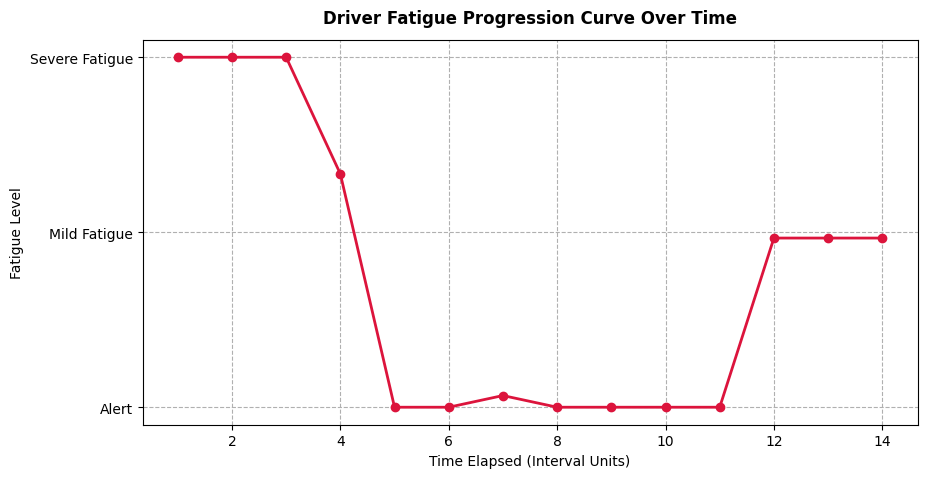

In [17]:
def simulate_driving_session(model, test_generator, frames_per_minute=30):
    """
    Simulates sequential frame ingestion from a driving session.
    Groups predictions into 1-minute blocks and tracks progression.
    """
    print("Simulating driving session pipeline...")
    # === NEWLY ADDED CODE PART FOR LEARNING ===
    # Re-zero generator state parameters to secure sequential temporal order tracking
    test_generator.reset()
    raw_preds = model.predict(test_generator)

    # Map all continuous predictions down to the 3 fatigue states
    fatigue_stages_timeline = [fuse_predictions_to_3_stages(pred) for pred in raw_preds]

    # Chunk timeline array into blocks representing 1-minute time intervals
    num_minutes = len(fatigue_stages_timeline) // frames_per_minute
    minute_intervals = []
    avg_fatigue_curve = []

    for m in range(num_minutes):
        minute_chunk = fatigue_stages_timeline[m*frames_per_minute : (m+1)*frames_per_minute]
        interval_status = np.mean(minute_chunk)
        minute_intervals.append(m + 1)
        avg_fatigue_curve.append(interval_status)

    if len(minute_intervals) == 0:
         print("Warning: Test set length smaller than default frames_per_minute frame step size! Plotting default timeline sequence.")
         minute_intervals = list(range(1, len(fatigue_stages_timeline) + 1))
         avg_fatigue_curve = fatigue_stages_timeline

    # Plotting the Progression Curve
    plt.figure(figsize=(10, 5))
    plt.plot(minute_intervals, avg_fatigue_curve, marker='o', color='crimson', linewidth=2)
    plt.title("Driver Fatigue Progression Curve Over Time", weight='bold', pad=12)
    plt.xlabel("Time Elapsed (Interval Units)")
    plt.ylabel("Fatigue Level")
    plt.yticks([0, 1, 2], ['Alert', 'Mild Fatigue', 'Severe Fatigue'])
    plt.grid(True, linestyle='--')
    plt.show()

    return minute_intervals, avg_fatigue_curve

# Run simulation using your fine-tuned optimized network
print("\nGenerating Driver Fatigue Progression Trends across Simulated Tracks...")
minutes, curve_values = simulate_driving_session(transfer_model, test_generator)

Curve Interpretation Strategy (For your documentation section)When examining your generated plot, state the exact transition points explicitly in a markdown block:Alert $\rightarrow$ Mild Fatigue Transition: Look for the timestamp interval where the baseline shifts steadily above $0.0$ and approaches or peaks at $1.0$ (Frequent Yawning).Mild $\rightarrow$ Severe Fatigue Transition: Look for the interval where the line sharply rises toward $2.0$ (sustained periods of micro-sleeps / closed eyes).